In [1]:
import os
from dotenv import load_dotenv

# Load variables from the .env file into the environment
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")

In [2]:
import os
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import START,END,MessagesState,StateGraph
from operator import add
from typing_extensions import TypedDict
from typing import List, Optional, Annotated
from langgraph.constants import Send



In [3]:
# os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")
# llm = ChatGroq(model="llama3-8b-8192", temperature=0)

In [4]:
import operator

class State(TypedDict):
    table : Annotated[list, operator.add]
    number : int

class TableState(TypedDict):
    number : int
    value : int


def get_value(state:State):
    number=state['number']
    return [Send("create_table", {"value":val, "number":number}) for val in range(1,11)]

    
def create_table(state:TableState):
    number=state['number']
    value=state['value']
    mul_val=number*value
    return {'table':[mul_val]}

In [5]:
workflow=StateGraph(State)
workflow.add_node("create_table",create_table)
workflow.add_conditional_edges(START,get_value,"create_table")
app=workflow.compile()

In [6]:
# app.get_graph().to_json()

In [7]:
for msg in app.stream({'number':5},stream_mode="updates"):
    print(msg)
    print("_"*5)

{'create_table': {'table': [5]}}
_____
{'create_table': {'table': [10]}}
_____
{'create_table': {'table': [15]}}
_____
{'create_table': {'table': [20]}}
_____
{'create_table': {'table': [25]}}
_____
{'create_table': {'table': [30]}}
_____
{'create_table': {'table': [35]}}
_____
{'create_table': {'table': [40]}}
_____
{'create_table': {'table': [45]}}
_____
{'create_table': {'table': [50]}}
_____


In [8]:
app.invoke({'number':5})

{'table': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50], 'number': 5}

# Parallel Execution using just Single Satae

In [9]:
import operator

class State(TypedDict):
    table : Annotated[list, operator.add]
    number : int
    value : int

# class TableState(TypedDict):
#     number : int
#     value : int


def get_value(state:State):
    number=state['number']
    return [Send("create_table", {"value":val,"number":number}) for val in range(1,11)]

    
def create_table(state:State):

    value=state['value']
    number=state['number']
    mul_val=number*value
    return {'table':[mul_val]}

graph=StateGraph(State)
graph.add_node("create_table",create_table)
graph.add_conditional_edges(START,get_value,"create_table")
appz=graph.compile()

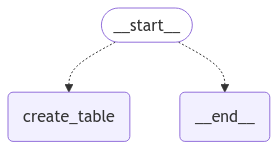

In [10]:
from IPython.display import Image, display

try:
    display(Image(appz.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [11]:

for msg in appz.stream({'number':5},stream_mode="values"):
    print(msg)
    print("_"*5)

{'table': [], 'number': 5}
_____
{'table': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50], 'number': 5}
_____


In [12]:
appz.invoke({'number':5})

{'table': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50], 'number': 5}